In [3]:
import h5py
import numpy as np
import re
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [4]:
# ------------------------------------------------------------------
# 1. List of files you want to scan (each with some MeV cut(s))
# ------------------------------------------------------------------
filepaths = [
    '/Users/justin/code/trajectum/cs_analysis/src/200GeV_0_800_MeVpTThresholds_SMASH.h5',
    '/Users/justin/code/trajectum/cs_analysis/src/200GeV_200_MeVpTThresholds_SMASH.h5',
    '/Users/justin/code/trajectum/cs_analysis/src/200GeV_400_500_MeVpTThresholds_SMASH.h5'
]


In [ ]:
# ------------------------------------------------------------------
# 2. Helper: process one file & return curves for each MeV cut
# ------------------------------------------------------------------
def get_fluctuation_curves_from_file(filepath):
    curves = []  # each element: (mev_label, centrality, y, yerr)

    with h5py.File(filepath, "r") as hdf:
        # centrality axis (common to all cuts in this file)
        centrality = hdf["centrality"][:].squeeze()

        # find all STARTPCxxxMeV groups under meanptcharged
        if "meanptcharged" not in hdf:
            raise KeyError(f"'meanptcharged' group not found in {filepath}")

        startpc_groups = [
            key for key in hdf["meanptcharged"].keys()
            if key.startswith("STARTPC")
        ]

        for grp in startpc_groups:
            # parse the MeV value from something like "STARTPC200MeV"
            m = re.search(r"(\d+)MeV", grp)
            mev_label = m.group(1) if m else grp  # "200" from "STARTPC200MeV"

            mean_base = f"meanptcharged/{grp}/centralitybinned"
            fluc_base = f"ptfluctuationscharged/{grp}/centralitybinned"

            # mean pT charged
            meanpTcharged_values = hdf[f"{mean_base}/values"][:].squeeze()
            meanpTcharged_uerr   = hdf[f"{mean_base}/uppererrors"][:].squeeze()
            meanpTcharged_lerr   = hdf[f"{mean_base}/lowererrors"][:].squeeze()
            meanpTcharged_symerr = 0.5 * (meanpTcharged_uerr + meanpTcharged_lerr)

            # delta pT
            deltapT_values = hdf[f"{fluc_base}/values"][:].squeeze()
            deltapT_uerr   = hdf[f"{fluc_base}/uppererrors"][:].squeeze()
            deltapT_lerr   = hdf[f"{fluc_base}/lowererrors"][:].squeeze()
            deltapT_symerr = 0.5 * (deltapT_uerr + deltapT_lerr)

            # δpT / ⟨pT⟩ in percent
            # normalizedfluctuation = (deltapT_values / meanpTcharged_values) * 100.0
            normalizedfluctuation = (deltapT_values / 1) * 100.0

            # error propagation
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio_err = normalizedfluctuation * np.sqrt(
                    (deltapT_symerr / deltapT_values)**2 +
                    (meanpTcharged_symerr / meanpTcharged_values)**2
                )

            # clean bad points
            mask = (
               np.isfinite(normalizedfluctuation) &
               np.isfinite(ratio_err) &
               (ratio_err >= 0)
            )

            #print(normalizedfluctuation)
            #print(ratio_err)

            curves.append((
                mev_label,
                centrality[mask],
                normalizedfluctuation[mask],
                ratio_err[mask],
            ))

    return curves


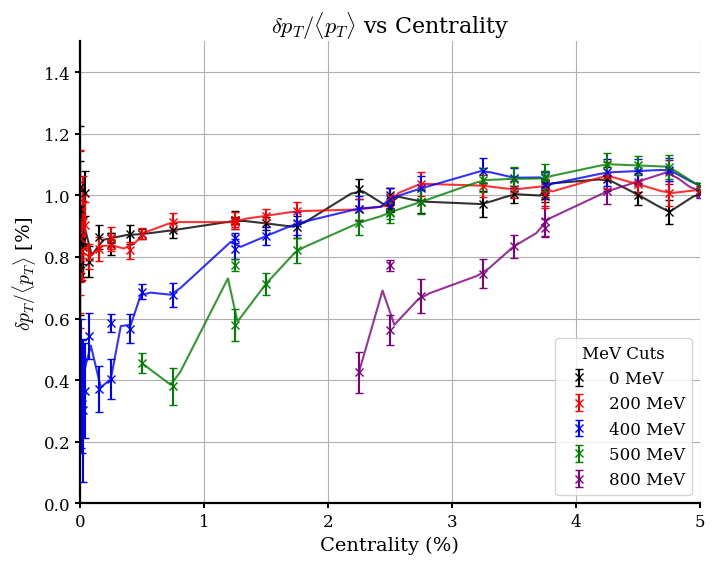

<Figure size 1200x1200 with 0 Axes>

In [15]:
# ------------------------------------------------------------------
# 3. Build plot: loop over files and MeV cuts
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))

color_map = {
    "200": "red",
    #"300": "blue",
    "400": "blue",
    "500": "green",
    "800": "purple"
}

for fp in filepaths:
    curves = get_fluctuation_curves_from_file(fp)

    for mev_label, x, y, yerr in curves:

        color = color_map.get(mev_label, "black")

        # interpolation for smooth curve
        if len(x) > 1:
            f = interp1d(x, y, kind="linear")
            x_new = np.linspace(x.min(), x.max(), 1000)
            y_new = f(x_new)

            plt.plot(x_new, y_new, "-", alpha=0.8, color=color)

        # data points with error bars
        plt.errorbar(
            x, y, yerr=yerr, fmt="x", capsize=3,
            color=color,
            label=fr"{mev_label} MeV"
        )


# ------------------------------------------------------------------
# 4. Formatting (STAR style, log x, etc.)
# ------------------------------------------------------------------
# plt.xscale("log")          # if you want log centrality like before
plt.xlabel("Centrality (%)", fontsize=14)
plt.ylabel(r"$\delta p_T / \langle p_T \rangle$ [%]", fontsize=14)
plt.title(r"$\delta p_T / \langle p_T \rangle$ vs Centrality", fontsize=16)
plt.xlim(0,5)
plt.ylim(0,1.5)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.6)
ax.spines['bottom'].set_linewidth(1.6)
ax.tick_params(axis='both', which='both', width=1.4, labelsize=12)

# ----- legend reorder -----
handles, labels = plt.gca().get_legend_handles_labels()
pairs = sorted(zip(handles, labels),
               key=lambda x: int(re.search(r"(\d+)", x[1]).group(1)))
new_handles, new_labels = zip(*pairs)
plt.grid()
plt.legend(new_handles, new_labels,title='MeV Cuts',fancybox=True,loc = "lower right")

plt.rcParams.update({"text.usetex": False, "mathtext.fontset": "cm",
                     "font.family": "serif", "font.size": 12})
plt.figure(figsize=(6, 6), dpi=200)

# plt.legend()
plt.tight_layout()
plt.show()

